In [49]:
import gffpandas.gffpandas as gffpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [17]:
counts = pd.read_csv('gene_counts.csv')
p_counts = pd.read_csv('promoter_methyl_counts')
genome = pd.read_csv('genetic_regions.csv')

In [19]:
# merging samples
frames = [ctrl_ph7, ctrl_ph5, arss_ph7, arss_ph5]
keys = ['ctrl pH7', 'ctrl pH5', 'arsS pH7', 'arsS pH5']
merged = pd.concat(frames, keys = keys)
merged = merged.reset_index(level=0).rename(columns={'level_0': 'sample'})
merged


,sample,seq_id,source,type,start,end,score,strand,phase,attributes,IPDRatio,context,coverage,id,identificationQv,motif
1,ctrl pH7,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,217,217,579,-,.,context=ACTCAAAAACCCTTGAATTGAGGGTGTTTTATACCTAA...,4.29,ACTCAAAAACCCTTGAATTGAGGGTGTTTTATACCTAAATT,547,GAGG,535,GAGG
2,ctrl pH7,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,255,255,713,+,.,context=AGTGAGCTTTTTGCTCAAAGAATCCAAGATAGCGTTTA...,5.35,AGTGAGCTTTTTGCTCAAAGAATCCAAGATAGCGTTTAAAA,534,GANTC,656,GANTC
3,ctrl pH7,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,257,257,604,-,.,context=ATTTTTAAACGCTATCTTGGATTCTTTGAGCAAAAAGC...,4.46,ATTTTTAAACGCTATCTTGGATTCTTTGAGCAAAAAGCTCA,548,GANTC,597,GANTC
6,ctrl pH7,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,300,300,740,+,.,context=AGGGGTGTTAGGCTCAGCGTAGAGTTTGCCAAGCTCTA...,5.36,AGGGGTGTTAGGCTCAGCGTAGAGTTTGCCAAGCTCTATGC,545,RCGDAD,695,RCGDAD
12,ctrl pH7,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,368,368,769,-,.,context=GATTTTACGCTTAGGAGCGTATGAAATTGGCTTCACGC...,5.78,GATTTTACGCTTAGGAGCGTATGAAATTGGCTTCACGCCCA,562,RCGDAD,738,RCGDAD
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
82780,arsS pH5,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,1667645,1667645,630,-,.,context=ACGCCAAGTACCCAAGAAGGATCGCTGAAGAATTGCAG...,5.54,ACGCCAAGTACCCAAGAAGGATCGCTGAAGAATTGCAGCGT,435,GATC,663,GATC
82782,arsS pH5,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,1667648,1667648,470,-,.,context=ATTACGCCAAGTACCCAAGAAGGATCGCTGAAGAATTG...,4.78,ATTACGCCAAGTACCCAAGAAGGATCGCTGAAGAATTGCAG,418,DGAAGG,447,DGAAGG
82783,arsS pH5,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,1667666,1667666,477,+,.,context=CCTTCTTGGGTACTTGGCGTAATCATAGCCATACCTTT...,4.39,CCTTCTTGGGTACTTGGCGTAATCATAGCCATACCTTTGGT,433,RCGDAD,451,RCGDAD
82784,arsS pH5,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,1667731,1667731,643,-,.,context=TGCGCTTGTTTATGATGAAGATGGCACACTAAGAATGA...,5.19,TGCGCTTGTTTATGATGAAGATGGCACACTAAGAATGAATG,431,GAAGA/TCTTC,644,GAAGA


In [23]:
ctrl_ph7 = genome[genome['sample'] == 'ctrl pH7']
ctrl_ph5 = genome[genome['sample'] == 'ctrl pH5']
ars_ph7 = genome[genome['sample'] == 'arsS pH7']
ars_ph5 = genome[genome['sample'] == 'arsS pH5']

In [25]:
ctrl_ph7

,Unnamed: 0,sample,seq_id,source,type,start,end,score,strand,phase,attributes,IPDRatio,context,coverage,id,identificationQv,motif,Classification,gene_ID,gene_type
0,0,ctrl pH7,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,217,217,579,-,.,context=ACTCAAAAACCCTTGAATTGAGGGTGTTTTATACCTAA...,4.29,ACTCAAAAACCCTTGAATTGAGGGTGTTTTATACCTAAATT,547,GAGG,535.0,GAGG,intergenic region,NaN,NaN
1,1,ctrl pH7,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,255,255,713,+,.,context=AGTGAGCTTTTTGCTCAAAGAATCCAAGATAGCGTTTA...,5.35,AGTGAGCTTTTTGCTCAAAGAATCCAAGATAGCGTTTAAAA,534,GANTC,656.0,GANTC,coding region,HP0001,TRANSCRIPTION
2,2,ctrl pH7,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,257,257,604,-,.,context=ATTTTTAAACGCTATCTTGGATTCTTTGAGCAAAAAGC...,4.46,ATTTTTAAACGCTATCTTGGATTCTTTGAGCAAAAAGCTCA,548,GANTC,597.0,GANTC,coding region,HP0001,TRANSCRIPTION
3,3,ctrl pH7,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,300,300,740,+,.,context=AGGGGTGTTAGGCTCAGCGTAGAGTTTGCCAAGCTCTA...,5.36,AGGGGTGTTAGGCTCAGCGTAGAGTTTGCCAAGCTCTATGC,545,RCGDAD,695.0,RCGDAD,coding region,HP0001,TRANSCRIPTION
4,4,ctrl pH7,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,368,368,769,-,.,context=GATTTTACGCTTAGGAGCGTATGAAATTGGCTTCACGC...,5.78,GATTTTACGCTTAGGAGCGTATGAAATTGGCTTCACGCCCA,562,RCGDAD,738.0,RCGDAD,coding region,HP0001,TRANSCRIPTION
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
59674,59674,ctrl pH7,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,1667648,1667648,575,-,.,context=ATTACGCCAAGTACCCAAGAAGGATCGCTGAAGAATTG...,4.99,ATTACGCCAAGTACCCAAGAAGGATCGCTGAAGAATTGCAG,541,DGAAGG,556.0,DGAAGG,coding region,HP1589,HYPOTHETICAL PROTEIEN
59675,59675,ctrl pH7,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,1667666,1667666,555,+,.,context=CCTTCTTGGGTACTTGGCGTAATCATAGCCATACCTTT...,4.30,CCTTCTTGGGTACTTGGCGTAATCATAGCCATACCTTTGGT,555,RCGDAD,526.0,RCGDAD,coding region,HP1589,HYPOTHETICAL PROTEIEN
59676,59676,ctrl pH7,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,1667716,1667716,125,+,.,coverage=561;context=AACTTGTCAATTATTCATTCATTCT...,2.04,AACTTGTCAATTATTCATTCATTCTTAGTGTGCCATCTTCA,561,NaN,69.0,NaN,coding region,HP1590,HYPOTHETICAL PROTEIEN
59677,59677,ctrl pH7,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,1667731,1667731,736,-,.,context=TGCGCTTGTTTATGATGAAGATGGCACACTAAGAATGA...,5.43,TGCGCTTGTTTATGATGAAGATGGCACACTAAGAATGAATG,553,GAAGA/TCTTC,776.0,GAAGA,coding region,HP1590,HYPOTHETICAL PROTEIEN


## Hypomethyl in Control, pH 7

In [396]:
bins = range(0, 1668732, 500)

In [398]:
ctrl_ph7['binned'] = pd.cut(ctrl_ph7['start'], bins, right=False)

/var/folders/kw/19vs2__d3bl_tx91fly_4sg40000gn/T/ipykernel_85008/2138070491.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ctrl_ph7['binned'] = pd.cut(ctrl_ph7['start'], bins, right=False)


In [400]:
ctrl_ph7

,Unnamed: 0,sample,seq_id,source,type,start,end,score,strand,phase,...,IPDRatio,context,coverage,id,identificationQv,motif,Classification,gene_ID,gene_type,binned
0,0,ctrl pH7,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,217,217,579,-,.,...,4.29,ACTCAAAAACCCTTGAATTGAGGGTGTTTTATACCTAAATT,547,GAGG,535.0,GAGG,intergenic region,NaN,NaN,"[0, 500)"
1,1,ctrl pH7,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,255,255,713,+,.,...,5.35,AGTGAGCTTTTTGCTCAAAGAATCCAAGATAGCGTTTAAAA,534,GANTC,656.0,GANTC,coding region,HP0001,TRANSCRIPTION,"[0, 500)"
2,2,ctrl pH7,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,257,257,604,-,.,...,4.46,ATTTTTAAACGCTATCTTGGATTCTTTGAGCAAAAAGCTCA,548,GANTC,597.0,GANTC,coding region,HP0001,TRANSCRIPTION,"[0, 500)"
3,3,ctrl pH7,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,300,300,740,+,.,...,5.36,AGGGGTGTTAGGCTCAGCGTAGAGTTTGCCAAGCTCTATGC,545,RCGDAD,695.0,RCGDAD,coding region,HP0001,TRANSCRIPTION,"[0, 500)"
4,4,ctrl pH7,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,368,368,769,-,.,...,5.78,GATTTTACGCTTAGGAGCGTATGAAATTGGCTTCACGCCCA,562,RCGDAD,738.0,RCGDAD,coding region,HP0001,TRANSCRIPTION,"[0, 500)"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
59674,59674,ctrl pH7,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,1667648,1667648,575,-,.,...,4.99,ATTACGCCAAGTACCCAAGAAGGATCGCTGAAGAATTGCAG,541,DGAAGG,556.0,DGAAGG,coding region,HP1589,HYPOTHETICAL PROTEIEN,"[1667500, 1668000)"
59675,59675,ctrl pH7,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,1667666,1667666,555,+,.,...,4.30,CCTTCTTGGGTACTTGGCGTAATCATAGCCATACCTTTGGT,555,RCGDAD,526.0,RCGDAD,coding region,HP1589,HYPOTHETICAL PROTEIEN,"[1667500, 1668000)"
59676,59676,ctrl pH7,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,1667716,1667716,125,+,.,...,2.04,AACTTGTCAATTATTCATTCATTCTTAGTGTGCCATCTTCA,561,NaN,69.0,NaN,coding region,HP1590,HYPOTHETICAL PROTEIEN,"[1667500, 1668000)"
59677,59677,ctrl pH7,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,1667731,1667731,736,-,.,...,5.43,TGCGCTTGTTTATGATGAAGATGGCACACTAAGAATGAATG,553,GAAGA/TCTTC,776.0,GAAGA,coding region,HP1590,HYPOTHETICAL PROTEIEN,"[1667500, 1668000)"


binned
[4000, 4500)          9
[25500, 26000)        8
[30000, 30500)        8
[30500, 31000)        4
[31000, 31500)        3
                     ..
[1614000, 1614500)    8
[1624000, 1624500)    7
[1646500, 1647000)    9
[1665500, 1666000)    9
[1668000, 1668500)    0
Name: count, Length: 240, dtype: int64


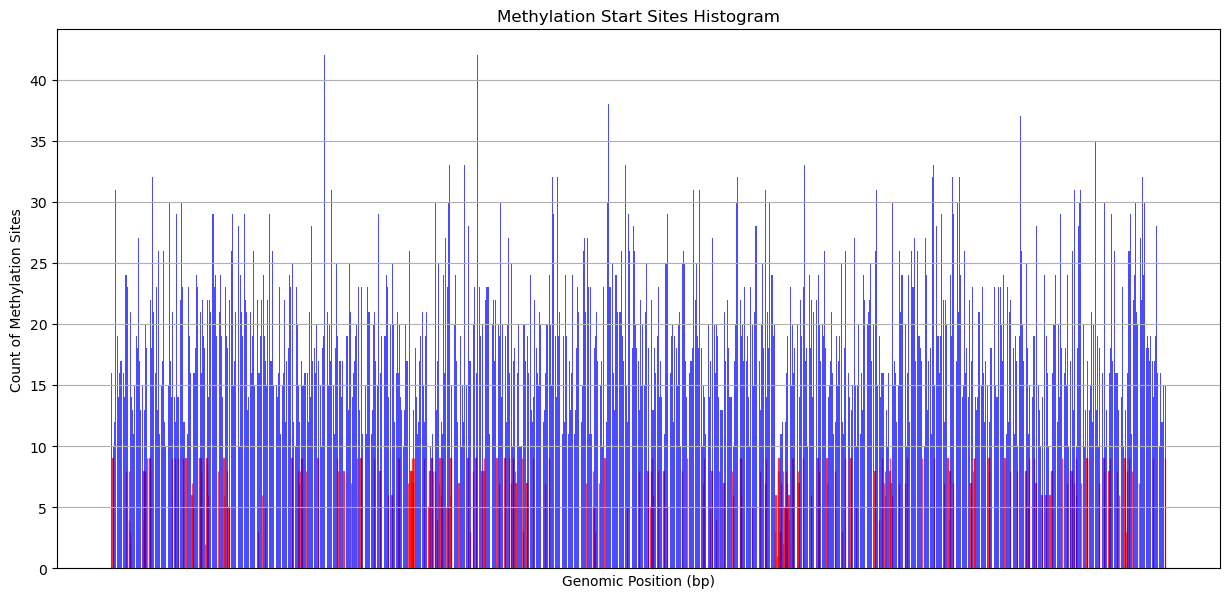

In [402]:
histogram_data = ctrl_ph7['binned'].value_counts().sort_index()

highlight_bins = histogram_data[histogram_data < 10]
print(highlight_bins)

plt.figure(figsize=(15, 7))
bars = plt.bar(histogram_data.index.astype(str), histogram_data.values, color='blue', alpha=0.7)

for bin_idx in highlight_bins.index:
    bars[histogram_data.index.get_loc(bin_idx)].set_color('red')

plt.title('Methylation Start Sites Histogram')
plt.xlabel('Genomic Position (bp)')
plt.ylabel('Count of Methylation Sites')


plt.grid(axis='y')
plt.xticks([], [])

plt.show()

In [403]:
#highlighting any bin which is less than 15

In [404]:
highlight_bins

binned
[4000, 4500)          9
[25500, 26000)        8
[30000, 30500)        8
[30500, 31000)        4
[31000, 31500)        3
                     ..
[1614000, 1614500)    8
[1624000, 1624500)    7
[1646500, 1647000)    9
[1665500, 1666000)    9
[1668000, 1668500)    0
Name: count, Length: 240, dtype: int64

In [405]:
ctrl_ph7

,Unnamed: 0,sample,seq_id,source,type,start,end,score,strand,phase,...,IPDRatio,context,coverage,id,identificationQv,motif,Classification,gene_ID,gene_type,binned
0,0,ctrl pH7,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,217,217,579,-,.,...,4.29,ACTCAAAAACCCTTGAATTGAGGGTGTTTTATACCTAAATT,547,GAGG,535.0,GAGG,intergenic region,NaN,NaN,"[0, 500)"
1,1,ctrl pH7,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,255,255,713,+,.,...,5.35,AGTGAGCTTTTTGCTCAAAGAATCCAAGATAGCGTTTAAAA,534,GANTC,656.0,GANTC,coding region,HP0001,TRANSCRIPTION,"[0, 500)"
2,2,ctrl pH7,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,257,257,604,-,.,...,4.46,ATTTTTAAACGCTATCTTGGATTCTTTGAGCAAAAAGCTCA,548,GANTC,597.0,GANTC,coding region,HP0001,TRANSCRIPTION,"[0, 500)"
3,3,ctrl pH7,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,300,300,740,+,.,...,5.36,AGGGGTGTTAGGCTCAGCGTAGAGTTTGCCAAGCTCTATGC,545,RCGDAD,695.0,RCGDAD,coding region,HP0001,TRANSCRIPTION,"[0, 500)"
4,4,ctrl pH7,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,368,368,769,-,.,...,5.78,GATTTTACGCTTAGGAGCGTATGAAATTGGCTTCACGCCCA,562,RCGDAD,738.0,RCGDAD,coding region,HP0001,TRANSCRIPTION,"[0, 500)"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
59674,59674,ctrl pH7,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,1667648,1667648,575,-,.,...,4.99,ATTACGCCAAGTACCCAAGAAGGATCGCTGAAGAATTGCAG,541,DGAAGG,556.0,DGAAGG,coding region,HP1589,HYPOTHETICAL PROTEIEN,"[1667500, 1668000)"
59675,59675,ctrl pH7,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,1667666,1667666,555,+,.,...,4.30,CCTTCTTGGGTACTTGGCGTAATCATAGCCATACCTTTGGT,555,RCGDAD,526.0,RCGDAD,coding region,HP1589,HYPOTHETICAL PROTEIEN,"[1667500, 1668000)"
59676,59676,ctrl pH7,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,1667716,1667716,125,+,.,...,2.04,AACTTGTCAATTATTCATTCATTCTTAGTGTGCCATCTTCA,561,NaN,69.0,NaN,coding region,HP1590,HYPOTHETICAL PROTEIEN,"[1667500, 1668000)"
59677,59677,ctrl pH7,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,1667731,1667731,736,-,.,...,5.43,TGCGCTTGTTTATGATGAAGATGGCACACTAAGAATGAATG,553,GAAGA/TCTTC,776.0,GAAGA,coding region,HP1590,HYPOTHETICAL PROTEIEN,"[1667500, 1668000)"


In [406]:
len(bins)

3338

In [407]:
highlight_ranges = [(interval.left, interval.right) for interval in highlight_bins.index] #list of tuples

def is_in_highlight_ranges(start_value, ranges):
    return any(start_value >= start and start_value < end for start, end in ranges)
filtered_data_c7 = ctrl_ph7[ctrl_ph7['start'].apply(is_in_highlight_ranges, ranges=highlight_ranges)]

filtered_data_c7

,Unnamed: 0,sample,seq_id,source,type,start,end,score,strand,phase,...,IPDRatio,context,coverage,id,identificationQv,motif,Classification,gene_ID,gene_type,binned
138,138,ctrl pH7,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,4034,4034,588,+,.,...,4.84,AGCTTTAGAAAAAATCCAGCAGGCCATAGATAAGGGCGAAA,538,GCAG,600.0,GCAG,coding region,HP0006,"BIOSYNTHESIS OF COFACTORS, PROSTHETIC GROUPS, ...","[4000, 4500)"
139,139,ctrl pH7,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,4360,4360,647,+,.,...,5.70,ATTATTTGAAAATAAAGCGTAGAAAATGATTTAAAAAGCAC,549,RCGDAD,603.0,RCGDAD,intergenic region,NaN,NaN,"[4000, 4500)"
140,140,ctrl pH7,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,4401,4401,625,+,.,...,4.83,TTGGTGGCGGAGCGGACGGGACTCGAACCCGCGACCCCCTG,550,GANTC,604.0,GANTC,intergenic region,NaN,NaN,"[4000, 4500)"
141,141,ctrl pH7,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,4403,4403,430,-,.,...,3.45,CGCAGGGGGTCGCGGGTTCGAGTCCCGTCCGCTCCGCCACC,542,"TCGA,GANTC",417.0,"TCGA,GANTC",intergenic region,NaN,NaN,"[4000, 4500)"
142,142,ctrl pH7,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,4406,4406,701,+,.,...,5.15,GGCGGAGCGGACGGGACTCGAACCCGCGACCCCCTGCGTGA,548,TCGA,685.0,TCGA,intergenic region,NaN,NaN,"[4000, 4500)"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
59610,59610,ctrl pH7,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,1665614,1665614,521,+,.,...,4.20,AACACACCCGCTAACTGCACATGAATATTGCACTACAAATG,530,CATG,501.0,CATG,intergenic region,NaN,NaN,"[1665500, 1666000)"
59611,59611,ctrl pH7,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,1665615,1665615,518,-,.,...,3.98,GCATTTGTAGTGCAATATTCATGTGCAGTTAGCGGGTGTGT,521,CATG,515.0,CATG,intergenic region,NaN,NaN,"[1665500, 1666000)"
59612,59612,ctrl pH7,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,1665811,1665811,485,-,.,...,4.29,AAGGGTTAGAGGGTTAAAGGAGGGGGTTTCTTGTGCTAGAA,524,GAGG,488.0,GAGG,intergenic region,NaN,NaN,"[1665500, 1666000)"
59613,59613,ctrl pH7,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,1665822,1665822,581,-,.,...,4.58,CGATAAAAAGTAAGGGTTAGAGGGTTAAAGGAGGGGGTTTC,522,GAGG,560.0,GAGG,intergenic region,NaN,NaN,"[1665500, 1666000)"


In [413]:
filtered_data_c7['gene_ID'].unique()
hypo_gene_ids = filtered_data_c7['gene_ID'].unique().tolist()

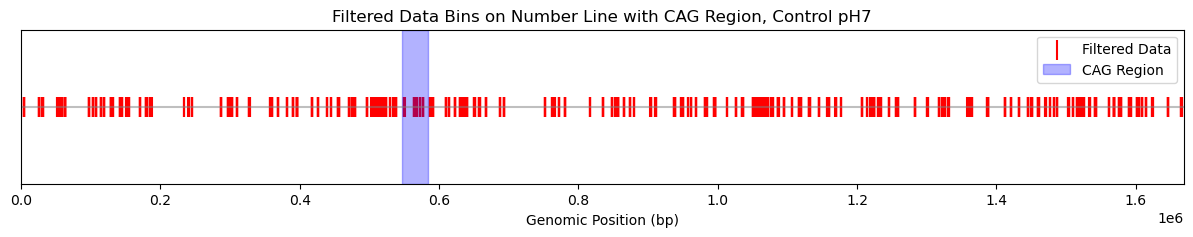

In [414]:
start_range = 0
end_range = 1668732

filtered_starts = filtered_data_c7['start']

cag_start = 547328
cag_end = 583478

plt.figure(figsize=(15, 2))
plt.hlines(1, xmin=start_range, xmax=end_range, color='grey', alpha=0.5)  # Base line

plt.scatter(filtered_starts, [1] * len(filtered_starts), color='red', marker='|', s=200, label='Filtered Data')

plt.axvspan(cag_start, cag_end, color='blue', alpha=0.3, label='CAG Region')

plt.xlim(start_range, end_range)
plt.yticks([])
plt.xlabel('Genomic Position (bp)')
plt.title('Filtered Data Bins on Number Line with CAG Region, Control pH7')

plt.legend()

plt.show()

In [415]:
unique_gene_ids_c7 = filtered_data_c7['gene_ID'].unique().tolist()
unique_gene_ids_c7

['HP0006',
 nan,
 'HP0025',
 'HP0029',
 'HP0030',
 'HP0052',
 'HP0053',
 'HP0054',
 'HP0056',
 'HP0058',
 'HP0059',
 'HP0091',
 'HP0098',
 'HP0101',
 'HP0107',
 'HP0111',
 'HP0118',
 'HP0119',
 'HP0120',
 'HPnc0470',
 'HPnc0480',
 'HP0132',
 'HP0133',
 'HP0139',
 'HP0141',
 'HP0142',
 'HP0143',
 'HPnc0580',
 'HP0172',
 'HP0173',
 'HP0174',
 'HP0178',
 'HP0180',
 'HP0225',
 'HP0229',
 'HP0230',
 'orphan',
 'HP0278',
 'HP0279',
 'HP0286',
 'HP0289',
 'HP0293',
 'HP0311',
 'HP0312',
 'HP0349',
 'HP0350',
 'HP0351',
 'HP0358',
 'HP0373',
 'HP0380',
 'HP0385',
 'HP0386',
 'HP0387',
 'HP0405',
 'HP0423',
 'HPnc1810',
 'HP0427',
 'HPr01',
 'HP0438',
 'HP0439',
 'HP0453',
 'HP0455',
 'HP0456',
 'HP0457',
 'HP0459',
 'HPnc2090',
 'HP0474',
 'HP0480',
 'HP0481',
 'HP0483',
 'HP0484',
 'HP0486',
 'HPnc2240',
 'HP0488',
 'HP0489',
 'HP0493',
 'HP0496',
 'HP0497',
 'HP0498',
 'HP0502',
 'HP0508',
 'HP0510',
 'HPnc2420',
 'HP0511',
 'HP0524',
 'HP0531',
 'HP0536',
 'HP0540',
 'HP0541',
 'HP0544',
 '

In [420]:
filtered_data_c7['gene_ID'].unique()

array(['HP0006', nan, 'HP0025', 'HP0029', 'HP0030', 'HP0052', 'HP0053',
       'HP0054', 'HP0056', 'HP0058', 'HP0059', 'HP0091', 'HP0098',
       'HP0101', 'HP0107', 'HP0111', 'HP0118', 'HP0119', 'HP0120',
       'HPnc0470', 'HPnc0480', 'HP0132', 'HP0133', 'HP0139', 'HP0141',
       'HP0142', 'HP0143', 'HPnc0580', 'HP0172', 'HP0173', 'HP0174',
       'HP0178', 'HP0180', 'HP0225', 'HP0229', 'HP0230', 'orphan',
       'HP0278', 'HP0279', 'HP0286', 'HP0289', 'HP0293', 'HP0311',
       'HP0312', 'HP0349', 'HP0350', 'HP0351', 'HP0358', 'HP0373',
       'HP0380', 'HP0385', 'HP0386', 'HP0387', 'HP0405', 'HP0423',
       'HPnc1810', 'HP0427', 'HPr01', 'HP0438', 'HP0439', 'HP0453',
       'HP0455', 'HP0456', 'HP0457', 'HP0459', 'HPnc2090', 'HP0474',
       'HP0480', 'HP0481', 'HP0483', 'HP0484', 'HP0486', 'HPnc2240',
       'HP0488', 'HP0489', 'HP0493', 'HP0496', 'HP0497', 'HP0498',
       'HP0502', 'HP0508', 'HP0510', 'HPnc2420', 'HP0511', 'HP0524',
       'HP0531', 'HP0536', 'HP0540', 'HP0541

In [422]:
annot_filtered = annot[annot['HP_number'].isin(unique_gene_ids_c7)]
annot_filtered

,HP_number,start,end,Putative_Id,Orf_Size,strand
5,HP0006,3403,4230,pantoate-beta-alanine ligase (panC) {Bacillus ...,827,+
24,HP0025,23327,25459,outer membrane protein (omp2),2132,-
28,HP0029,29414,30067,dethiobiotin synthetase (bioD) {Methanococcus ...,653,-
29,HP0030,30074,31852,hypothetical protein,1778,-
51,HP0052,51275,52264,hypothetical protein,989,-
...,...,...,...,...,...,...
1533,HP1534,1613004,1614284,IS605 transposase (tnpB) {Helicobacter pylori},1280,-
1534,HP1535,1614354,1614779,IS605 transposase (tnpA) {Helicobacter pylori},425,+
1544,HP1545,1623817,1624998,folylpolyglutamate synthase (folC) {Haemophilu...,1181,-
1563,HP1564,1645960,1646772,outer membrane protein {Pasteurella haemolytica},812,+


In [424]:
hypo_genes_c7 = annot_filtered['HP_number'].tolist()
hypo_genes_c7

['HP0006',
 'HP0025',
 'HP0029',
 'HP0030',
 'HP0052',
 'HP0053',
 'HP0054',
 'HP0056',
 'HP0058',
 'HP0059',
 'HP0091',
 'HP0098',
 'HP0101',
 'HP0107',
 'HP0111',
 'HP0118',
 'HP0119',
 'HP0120',
 'HP0132',
 'HP0133',
 'HP0139',
 'HP0141',
 'HP0142',
 'HP0143',
 'HP0172',
 'HP0173',
 'HP0174',
 'HP0178',
 'HP0180',
 'HP0225',
 'HP0229',
 'HP0230',
 'HP0278',
 'HP0279',
 'HP0286',
 'HP0289',
 'HP0293',
 'HP0311',
 'HP0312',
 'HP0349',
 'HP0350',
 'HP0351',
 'HP0358',
 'HP0373',
 'HP0380',
 'HP0385',
 'HP0386',
 'HP0387',
 'HP0405',
 'HP0423',
 'HP0427',
 'HP0438',
 'HP0439',
 'HP0453',
 'HP0455',
 'HP0456',
 'HP0457',
 'HP0459',
 'HP0474',
 'HP0480',
 'HP0481',
 'HP0483',
 'HP0484',
 'HP0486',
 'HP0488',
 'HP0489',
 'HP0493',
 'HP0496',
 'HP0497',
 'HP0498',
 'HP0502',
 'HP0508',
 'HP0510',
 'HP0511',
 'HP0524',
 'HP0531',
 'HP0536',
 'HP0540',
 'HP0541',
 'HP0544',
 'HP0550',
 'HP0554',
 'HP0555',
 'HP0556',
 'HP0578',
 'HP0579',
 'HP0583',
 'HP0591',
 'HP0592',
 'HP0596',
 'HP0598',

In [255]:
genome_hypo_ctrl7 = ctrl_ph7[ctrl_ph7['gene_ID'].isin(unique_gene_ids)]
genome_hypo_ctrl7['gene_type'].value_counts()

gene_type
HYPOTHETICAL PROTEIEN                                         2573
CELL ENVELOPE                                                 1702
REPLICATION                                                   1037
TRANSPORT AND BINDING PROTEINS                                 767
CELLULAR PROCESSES                                             578
ENERGY METABOLISM                                              556
BIOSYNTHESIS OF COFACTORS, PROSTHETIC GROUPS, AND CARRIERS     289
AMINO-ACID BIOSYNTHESIS                                        264
OTHER CATEGORIES                                               209
TRANSLATION                                                    179
REGULATORY FUNCTIONS                                           153
TRANSCRIPTION                                                   87
PURINES, PYRIMIDINES, NUCLEOSIDES AND NUCLEOTIDES               72
CENTRAL INTERMEDIARY METABOLISM                                 59
Name: count, dtype: int64

In [287]:
genome_hypo_ctrl7

,Unnamed: 0,sample,seq_id,source,type,start,end,score,strand,phase,...,IPDRatio,context,coverage,id,identificationQv,motif,Classification,gene_ID,gene_type,binned
0,0,ctrl pH7,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,217,217,579,-,.,...,4.29,ACTCAAAAACCCTTGAATTGAGGGTGTTTTATACCTAAATT,547,GAGG,535.0,GAGG,intergenic region,NaN,NaN,"[0, 500)"
121,121,ctrl pH7,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m4C,3457,3457,654,-,.,...,5.08,CGGCACAAACCCCACGCTTTCTTCCAAACTTTTACGATACT,533,GAAGA/TCTTC,626.0,TCTTC,coding region,HP0006,"BIOSYNTHESIS OF COFACTORS, PROSTHETIC GROUPS, ...","[3000, 3500)"
122,122,ctrl pH7,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,3458,3458,516,+,.,...,4.36,GTATCGTAAAAGTTTGGAAGAAAGCGTGGGGTTTGTGCCGA,509,GAAGA/TCTTC,493.0,GAAGA,coding region,HP0006,"BIOSYNTHESIS OF COFACTORS, PROSTHETIC GROUPS, ...","[3000, 3500)"
123,123,ctrl pH7,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m4C,3592,3592,577,-,.,...,4.14,GCGAGGGTAAGCGTTAAAATCTTCGTTAGCCCCAAATTGCG,547,GAAGA/TCTTC,552.0,TCTTC,coding region,HP0006,"BIOSYNTHESIS OF COFACTORS, PROSTHETIC GROUPS, ...","[3500, 4000)"
124,124,ctrl pH7,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,3593,3593,703,+,.,...,5.51,GCAATTTGGGGCTAACGAAGATTTTAACGCTTACCCTCGCC,541,GAAGA/TCTTC,657.0,GAAGA,coding region,HP0006,"BIOSYNTHESIS OF COFACTORS, PROSTHETIC GROUPS, ...","[3500, 4000)"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
59610,59610,ctrl pH7,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,1665614,1665614,521,+,.,...,4.20,AACACACCCGCTAACTGCACATGAATATTGCACTACAAATG,530,CATG,501.0,CATG,intergenic region,NaN,NaN,"[1665500, 1666000)"
59611,59611,ctrl pH7,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,1665615,1665615,518,-,.,...,3.98,GCATTTGTAGTGCAATATTCATGTGCAGTTAGCGGGTGTGT,521,CATG,515.0,CATG,intergenic region,NaN,NaN,"[1665500, 1666000)"
59612,59612,ctrl pH7,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,1665811,1665811,485,-,.,...,4.29,AAGGGTTAGAGGGTTAAAGGAGGGGGTTTCTTGTGCTAGAA,524,GAGG,488.0,GAGG,intergenic region,NaN,NaN,"[1665500, 1666000)"
59613,59613,ctrl pH7,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,1665822,1665822,581,-,.,...,4.58,CGATAAAAAGTAAGGGTTAGAGGGTTAAAGGAGGGGGTTTC,522,GAGG,560.0,GAGG,intergenic region,NaN,NaN,"[1665500, 1666000)"


## Hypomethyl in Control, pH 5

In [428]:
bins = range(0, 1668732, 500)
ctrl_ph5['binned'] = pd.cut(ctrl_ph5['start'], bins, right=False)

/var/folders/kw/19vs2__d3bl_tx91fly_4sg40000gn/T/ipykernel_85008/1471649331.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ctrl_ph5['binned'] = pd.cut(ctrl_ph5['start'], bins, right=False)


binned
[4000, 4500)          9
[5500, 6000)          9
[25500, 26000)        8
[30000, 30500)        8
[30500, 31000)        4
                     ..
[1614000, 1614500)    8
[1624000, 1624500)    7
[1646500, 1647000)    9
[1665500, 1666000)    9
[1668000, 1668500)    0
Name: count, Length: 242, dtype: int64


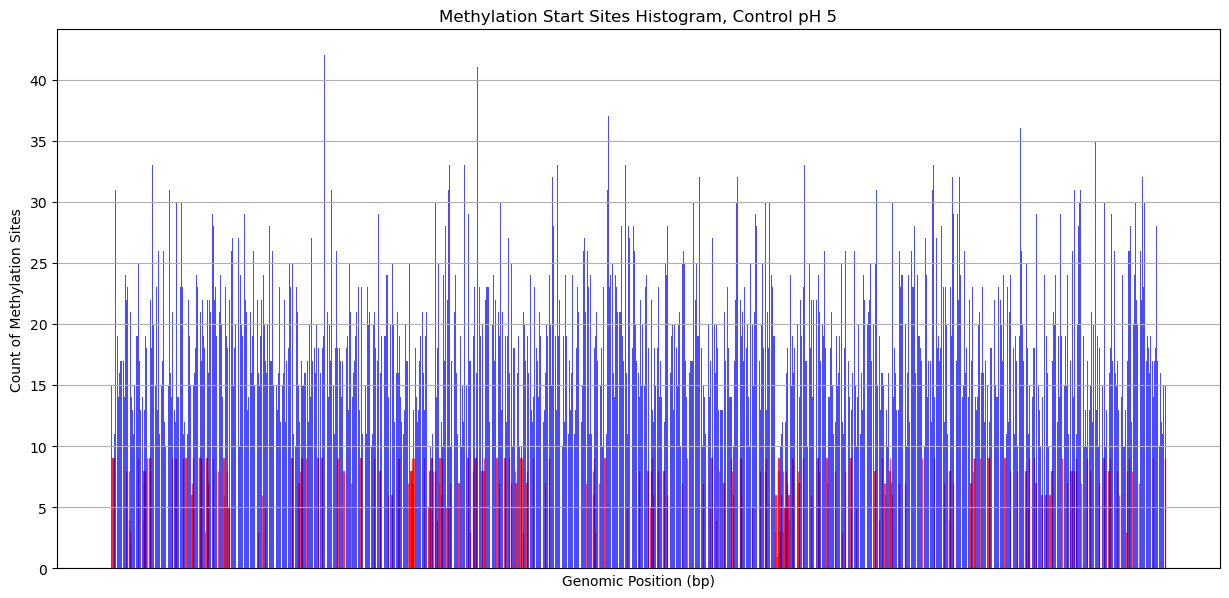

In [432]:
histogram_data = ctrl_ph5['binned'].value_counts().sort_index()

highlight_bins = histogram_data[histogram_data < 10]
print(highlight_bins)

plt.figure(figsize=(15, 7))
bars = plt.bar(histogram_data.index.astype(str), histogram_data.values, color='blue', alpha=0.7)

for bin_idx in highlight_bins.index:
    bars[histogram_data.index.get_loc(bin_idx)].set_color('red')

plt.title('Methylation Start Sites Histogram, Control pH 5')
plt.xlabel('Genomic Position (bp)')
plt.ylabel('Count of Methylation Sites')


plt.grid(axis='y')
plt.xticks([], [])

plt.show()

In [434]:
highlight_ranges = [(interval.left, interval.right) for interval in highlight_bins.index] #list of tuples

def is_in_highlight_ranges(start_value, ranges):
    return any(start_value >= start and start_value < end for start, end in ranges)
filtered_data_ph5 = ctrl_ph5[ctrl_ph5['start'].apply(is_in_highlight_ranges, ranges=highlight_ranges)]

filtered_data_ph5

,Unnamed: 0,sample,seq_id,source,type,start,end,score,strand,phase,...,IPDRatio,context,coverage,id,identificationQv,motif,Classification,gene_ID,gene_type,binned
59819,59819,ctrl pH5,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,4034,4034,586,+,.,...,5.08,AGCTTTAGAAAAAATCCAGCAGGCCATAGATAAGGGCGAAA,500,GCAG,603.0,GCAG,coding region,HP0006,"BIOSYNTHESIS OF COFACTORS, PROSTHETIC GROUPS, ...","[4000, 4500)"
59820,59820,ctrl pH5,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,4360,4360,686,+,.,...,5.69,ATTATTTGAAAATAAAGCGTAGAAAATGATTTAAAAAGCAC,498,RCGDAD,656.0,RCGDAD,intergenic region,NaN,NaN,"[4000, 4500)"
59821,59821,ctrl pH5,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,4401,4401,501,+,.,...,4.31,TTGGTGGCGGAGCGGACGGGACTCGAACCCGCGACCCCCTG,502,GANTC,487.0,GANTC,intergenic region,NaN,NaN,"[4000, 4500)"
59822,59822,ctrl pH5,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,4403,4403,412,-,.,...,3.43,CGCAGGGGGTCGCGGGTTCGAGTCCCGTCCGCTCCGCCACC,515,"TCGA,GANTC",397.0,"TCGA,GANTC",intergenic region,NaN,NaN,"[4000, 4500)"
59823,59823,ctrl pH5,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,4406,4406,620,+,.,...,5.01,GGCGGAGCGGACGGGACTCGAACCCGCGACCCCCTGCGTGA,503,TCGA,584.0,TCGA,intergenic region,NaN,NaN,"[4000, 4500)"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
119279,119279,ctrl pH5,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,1665614,1665614,524,+,.,...,4.41,AACACACCCGCTAACTGCACATGAATATTGCACTACAAATG,493,CATG,501.0,CATG,intergenic region,NaN,NaN,"[1665500, 1666000)"
119280,119280,ctrl pH5,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,1665615,1665615,475,-,.,...,4.08,GCATTTGTAGTGCAATATTCATGTGCAGTTAGCGGGTGTGT,496,CATG,474.0,CATG,intergenic region,NaN,NaN,"[1665500, 1666000)"
119281,119281,ctrl pH5,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,1665811,1665811,483,-,.,...,4.30,AAGGGTTAGAGGGTTAAAGGAGGGGGTTTCTTGTGCTAGAA,507,GAGG,475.0,GAGG,intergenic region,NaN,NaN,"[1665500, 1666000)"
119282,119282,ctrl pH5,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,1665822,1665822,631,-,.,...,4.95,CGATAAAAAGTAAGGGTTAGAGGGTTAAAGGAGGGGGTTTC,506,GAGG,619.0,GAGG,intergenic region,NaN,NaN,"[1665500, 1666000)"


In [301]:
filtered_data_ph5['gene_ID'].unique()
hypo_gene_ids5 = filtered_data_ph5['gene_ID'].unique().tolist()

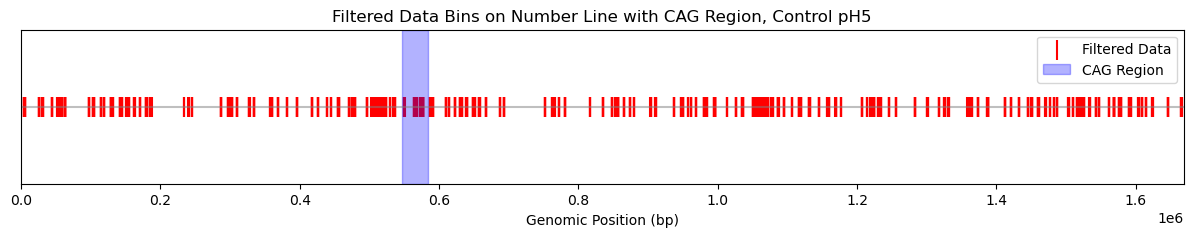

In [436]:
start_range = 0
end_range = 1668732

filtered_starts = filtered_data_ph5['start']

cag_start = 547328
cag_end = 583478

plt.figure(figsize=(15, 2))
plt.hlines(1, xmin=start_range, xmax=end_range, color='grey', alpha=0.5)  # Base line

plt.scatter(filtered_starts, [1] * len(filtered_starts), color='red', marker='|', s=200, label='Filtered Data')

plt.axvspan(cag_start, cag_end, color='blue', alpha=0.3, label='CAG Region')

plt.xlim(start_range, end_range)
plt.yticks([])
plt.xlabel('Genomic Position (bp)')
plt.title('Filtered Data Bins on Number Line with CAG Region, Control pH5')

plt.legend()

plt.show()

In [438]:
unique_gene_ids5 = filtered_data_ph5['gene_ID'].unique().tolist()
annot_filtered = annot[annot['HP_number'].isin(unique_gene_ids5)]
annot_filtered

,HP_number,start,end,Putative_Id,Orf_Size,strand
5,HP0006,3403,4230,pantoate-beta-alanine ligase (panC) {Bacillus ...,827,+
8,HP0009,5244,7145,outer membrane protein (omp1),1901,-
24,HP0025,23327,25459,outer membrane protein (omp2),2132,-
28,HP0029,29414,30067,dethiobiotin synthetase (bioD) {Methanococcus ...,653,-
29,HP0030,30074,31852,hypothetical protein,1778,-
...,...,...,...,...,...,...
1533,HP1534,1613004,1614284,IS605 transposase (tnpB) {Helicobacter pylori},1280,-
1534,HP1535,1614354,1614779,IS605 transposase (tnpA) {Helicobacter pylori},425,+
1544,HP1545,1623817,1624998,folylpolyglutamate synthase (folC) {Haemophilu...,1181,-
1563,HP1564,1645960,1646772,outer membrane protein {Pasteurella haemolytica},812,+


In [440]:
hypo_genes_c5 = annot_filtered['HP_number'].tolist()
hypo_genes_c5

['HP0006',
 'HP0009',
 'HP0025',
 'HP0029',
 'HP0030',
 'HP0052',
 'HP0053',
 'HP0054',
 'HP0056',
 'HP0058',
 'HP0059',
 'HP0091',
 'HP0098',
 'HP0099',
 'HP0107',
 'HP0111',
 'HP0118',
 'HP0119',
 'HP0120',
 'HP0132',
 'HP0133',
 'HP0139',
 'HP0140',
 'HP0141',
 'HP0142',
 'HP0143',
 'HP0152',
 'HP0153',
 'HP0172',
 'HP0173',
 'HP0174',
 'HP0178',
 'HP0180',
 'HP0225',
 'HP0229',
 'HP0230',
 'HP0278',
 'HP0279',
 'HP0286',
 'HP0289',
 'HP0293',
 'HP0311',
 'HP0312',
 'HP0317',
 'HP0318',
 'HP0349',
 'HP0350',
 'HP0351',
 'HP0358',
 'HP0373',
 'HP0385',
 'HP0386',
 'HP0387',
 'HP0405',
 'HP0423',
 'HP0427',
 'HP0438',
 'HP0439',
 'HP0453',
 'HP0455',
 'HP0456',
 'HP0457',
 'HP0459',
 'HP0474',
 'HP0480',
 'HP0481',
 'HP0483',
 'HP0484',
 'HP0486',
 'HP0488',
 'HP0489',
 'HP0493',
 'HP0496',
 'HP0497',
 'HP0498',
 'HP0502',
 'HP0508',
 'HP0510',
 'HP0524',
 'HP0531',
 'HP0536',
 'HP0540',
 'HP0541',
 'HP0543',
 'HP0544',
 'HP0550',
 'HP0554',
 'HP0555',
 'HP0556',
 'HP0578',
 'HP0579',

## Ars pH7

In [336]:
bins = range(0, 1668732, 500)
ars_ph7['binned'] = pd.cut(ars_ph7['start'], bins, right=False)

/var/folders/kw/19vs2__d3bl_tx91fly_4sg40000gn/T/ipykernel_85008/1885869572.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ars_ph7['binned'] = pd.cut(ars_ph7['start'], bins, right=False)


binned
[4000, 4500)          9
[5500, 6000)          9
[25500, 26000)        8
[30000, 30500)        7
[30500, 31000)        4
                     ..
[1614000, 1614500)    8
[1624000, 1624500)    7
[1646500, 1647000)    9
[1665500, 1666000)    9
[1668000, 1668500)    0
Name: count, Length: 266, dtype: int64


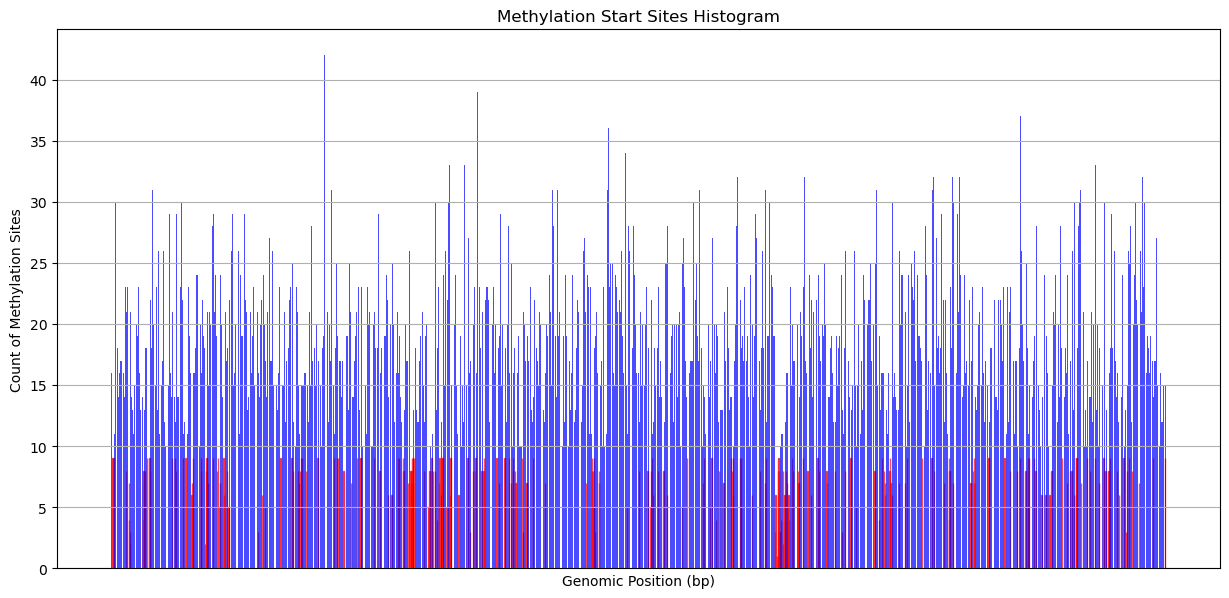

In [338]:
histogram_data = ars_ph7['binned'].value_counts().sort_index()

highlight_bins = histogram_data[histogram_data < 10]
print(highlight_bins)

plt.figure(figsize=(15, 7))
bars = plt.bar(histogram_data.index.astype(str), histogram_data.values, color='blue', alpha=0.7)

for bin_idx in highlight_bins.index:
    bars[histogram_data.index.get_loc(bin_idx)].set_color('red')

plt.title('Methylation Start Sites Histogram')
plt.xlabel('Genomic Position (bp)')
plt.ylabel('Count of Methylation Sites')


plt.grid(axis='y')
plt.xticks([], [])

plt.show()

In [342]:
highlight_ranges = [(interval.left, interval.right) for interval in highlight_bins.index] #list of tuples

def is_in_highlight_ranges(start_value, ranges):
    return any(start_value >= start and start_value < end for start, end in ranges)
filtered_data_ars7 = ars_ph7[ars_ph7['start'].apply(is_in_highlight_ranges, ranges=highlight_ranges)]

filtered_data_ars7

,Unnamed: 0,sample,seq_id,source,type,start,end,score,strand,phase,...,IPDRatio,context,coverage,id,identificationQv,motif,Classification,gene_ID,gene_type,binned
119484,119484,arsS pH7,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,4034,4034,573,+,.,...,4.31,AGCTTTAGAAAAAATCCAGCAGGCCATAGATAAGGGCGAAA,560,GCAG,591.0,GCAG,coding region,HP0006,"BIOSYNTHESIS OF COFACTORS, PROSTHETIC GROUPS, ...","[4000, 4500)"
119485,119485,arsS pH7,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,4360,4360,776,+,.,...,5.48,ATTATTTGAAAATAAAGCGTAGAAAATGATTTAAAAAGCAC,579,RCGDAD,745.0,RCGDAD,intergenic region,NaN,NaN,"[4000, 4500)"
119486,119486,arsS pH7,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,4401,4401,572,+,.,...,4.31,TTGGTGGCGGAGCGGACGGGACTCGAACCCGCGACCCCCTG,578,GANTC,572.0,GANTC,intergenic region,NaN,NaN,"[4000, 4500)"
119487,119487,arsS pH7,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,4403,4403,545,-,.,...,4.15,CGCAGGGGGTCGCGGGTTCGAGTCCCGTCCGCTCCGCCACC,569,"TCGA,GANTC",547.0,"TCGA,GANTC",intergenic region,NaN,NaN,"[4000, 4500)"
119488,119488,arsS pH7,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,4406,4406,716,+,.,...,5.05,GGCGGAGCGGACGGGACTCGAACCCGCGACCCCCTGCGTGA,574,TCGA,686.0,TCGA,intergenic region,NaN,NaN,"[4000, 4500)"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
178192,178192,arsS pH7,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,1665614,1665614,520,+,.,...,4.01,AACACACCCGCTAACTGCACATGAATATTGCACTACAAATG,579,CATG,498.0,CATG,intergenic region,NaN,NaN,"[1665500, 1666000)"
178193,178193,arsS pH7,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,1665615,1665615,470,-,.,...,3.54,GCATTTGTAGTGCAATATTCATGTGCAGTTAGCGGGTGTGT,570,CATG,465.0,CATG,intergenic region,NaN,NaN,"[1665500, 1666000)"
178194,178194,arsS pH7,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,1665811,1665811,509,-,.,...,4.29,AAGGGTTAGAGGGTTAAAGGAGGGGGTTTCTTGTGCTAGAA,575,GAGG,522.0,GAGG,intergenic region,NaN,NaN,"[1665500, 1666000)"
178195,178195,arsS pH7,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,1665822,1665822,624,-,.,...,4.76,CGATAAAAAGTAAGGGTTAGAGGGTTAAAGGAGGGGGTTTC,575,GAGG,609.0,GAGG,intergenic region,NaN,NaN,"[1665500, 1666000)"


In [344]:
filtered_data_ars7['gene_ID'].unique()
hypo_gene_ids_a7 = filtered_data_ars7['gene_ID'].unique().tolist()

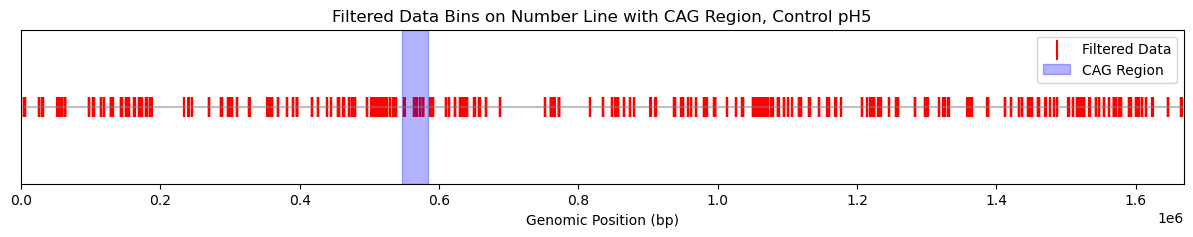

In [346]:
start_range = 0
end_range = 1668732

filtered_starts = filtered_data_ars7['start']

cag_start = 547328
cag_end = 583478

plt.figure(figsize=(15, 2))
plt.hlines(1, xmin=start_range, xmax=end_range, color='grey', alpha=0.5)  # Base line

plt.scatter(filtered_starts, [1] * len(filtered_starts), color='red', marker='|', s=200, label='Filtered Data')

plt.axvspan(cag_start, cag_end, color='blue', alpha=0.3, label='CAG Region')

plt.xlim(start_range, end_range)
plt.yticks([])
plt.xlabel('Genomic Position (bp)')
plt.title('Filtered Data Bins on Number Line with CAG Region, Control pH5')

plt.legend()

plt.show()

In [348]:
unique_gene_ids_a7 = filtered_data_ars7['gene_ID'].unique().tolist()
annot_filtered_a7 = annot[annot['HP_number'].isin(unique_gene_ids_a7)]
annot_filtered_a7

,HP_number,start,end,Putative_Id,Orf_Size,strand
5,HP0006,3403,4230,pantoate-beta-alanine ligase (panC) {Bacillus ...,827,+
8,HP0009,5244,7145,outer membrane protein (omp1),1901,-
24,HP0025,23327,25459,outer membrane protein (omp2),2132,-
28,HP0029,29414,30067,dethiobiotin synthetase (bioD) {Methanococcus ...,653,-
29,HP0030,30074,31852,hypothetical protein,1778,-
...,...,...,...,...,...,...
1533,HP1534,1613004,1614284,IS605 transposase (tnpB) {Helicobacter pylori},1280,-
1534,HP1535,1614354,1614779,IS605 transposase (tnpA) {Helicobacter pylori},425,+
1544,HP1545,1623817,1624998,folylpolyglutamate synthase (folC) {Haemophilu...,1181,-
1563,HP1564,1645960,1646772,outer membrane protein {Pasteurella haemolytica},812,+


In [373]:
hypo_genes_a7 = annot_filtered_a7['HP_number'].tolist()
hypo_genes_a7

['HP0006',
 'HP0009',
 'HP0025',
 'HP0029',
 'HP0030',
 'HP0052',
 'HP0053',
 'HP0054',
 'HP0056',
 'HP0058',
 'HP0059',
 'HP0091',
 'HP0098',
 'HP0099',
 'HP0107',
 'HP0111',
 'HP0118',
 'HP0119',
 'HP0120',
 'HP0132',
 'HP0133',
 'HP0139',
 'HP0140',
 'HP0141',
 'HP0142',
 'HP0143',
 'HP0152',
 'HP0153',
 'HP0160',
 'HP0161',
 'HP0163',
 'HP0164',
 'HP0165',
 'HP0166',
 'HP0172',
 'HP0173',
 'HP0174',
 'HP0178',
 'HP0180',
 'HP0225',
 'HP0229',
 'HP0230',
 'HP0259',
 'HP0260',
 'HP0278',
 'HP0279',
 'HP0280',
 'HP0281',
 'HP0286',
 'HP0289',
 'HP0293',
 'HP0311',
 'HP0312',
 'HP0346',
 'HP0349',
 'HP0350',
 'HP0351',
 'HP0358',
 'HP0373',
 'HP0380',
 'HP0385',
 'HP0386',
 'HP0387',
 'HP0405',
 'HP0423',
 'HP0427',
 'HP0438',
 'HP0439',
 'HP0444',
 'HP0453',
 'HP0455',
 'HP0456',
 'HP0457',
 'HP0459',
 'HP0474',
 'HP0480',
 'HP0481',
 'HP0483',
 'HP0484',
 'HP0486',
 'HP0488',
 'HP0489',
 'HP0493',
 'HP0496',
 'HP0497',
 'HP0498',
 'HP0499',
 'HP0502',
 'HP0508',
 'HP0510',
 'HP0511',

## Ars pH5

In [355]:
bins = range(0, 1668732, 500)
ars_ph5['binned'] = pd.cut(ars_ph5['start'], bins, right=False)

/var/folders/kw/19vs2__d3bl_tx91fly_4sg40000gn/T/ipykernel_85008/245197064.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ars_ph5['binned'] = pd.cut(ars_ph5['start'], bins, right=False)


binned
[4000, 4500)          9
[5500, 6000)          9
[25500, 26000)        8
[30000, 30500)        7
[30500, 31000)        4
                     ..
[1608500, 1609000)    9
[1614000, 1614500)    9
[1624000, 1624500)    7
[1665500, 1666000)    9
[1668000, 1668500)    0
Name: count, Length: 266, dtype: int64


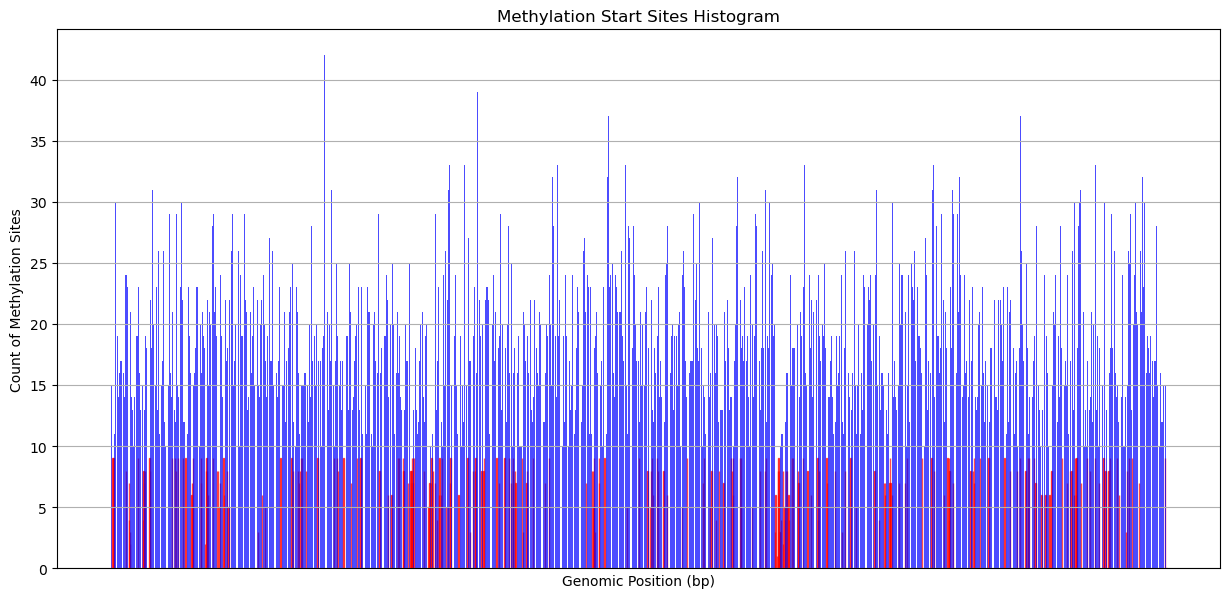

In [357]:
histogram_data = ars_ph5['binned'].value_counts().sort_index()

highlight_bins = histogram_data[histogram_data < 10]
print(highlight_bins)

plt.figure(figsize=(15, 7))
bars = plt.bar(histogram_data.index.astype(str), histogram_data.values, color='blue', alpha=0.7)

for bin_idx in highlight_bins.index:
    bars[histogram_data.index.get_loc(bin_idx)].set_color('red')

plt.title('Methylation Start Sites Histogram')
plt.xlabel('Genomic Position (bp)')
plt.ylabel('Count of Methylation Sites')


plt.grid(axis='y')
plt.xticks([], [])

plt.show()

In [359]:
highlight_ranges = [(interval.left, interval.right) for interval in highlight_bins.index] #list of tuples

def is_in_highlight_ranges(start_value, ranges):
    return any(start_value >= start and start_value < end for start, end in ranges)
filtered_data_ars5 = ars_ph5[ars_ph5['start'].apply(is_in_highlight_ranges, ranges=highlight_ranges)]

filtered_data_ars5

,Unnamed: 0,sample,seq_id,source,type,start,end,score,strand,phase,...,IPDRatio,context,coverage,id,identificationQv,motif,Classification,gene_ID,gene_type,binned
178394,178394,arsS pH5,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,4034,4034,549,+,.,...,4.79,AGCTTTAGAAAAAATCCAGCAGGCCATAGATAAGGGCGAAA,448,GCAG,566.0,GCAG,coding region,HP0006,"BIOSYNTHESIS OF COFACTORS, PROSTHETIC GROUPS, ...","[4000, 4500)"
178395,178395,arsS pH5,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,4360,4360,564,+,.,...,5.62,ATTATTTGAAAATAAAGCGTAGAAAATGATTTAAAAAGCAC,439,RCGDAD,527.0,RCGDAD,intergenic region,NaN,NaN,"[4000, 4500)"
178396,178396,arsS pH5,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,4401,4401,481,+,.,...,4.50,TTGGTGGCGGAGCGGACGGGACTCGAACCCGCGACCCCCTG,438,GANTC,468.0,GANTC,intergenic region,NaN,NaN,"[4000, 4500)"
178397,178397,arsS pH5,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,4403,4403,409,-,.,...,3.99,CGCAGGGGGTCGCGGGTTCGAGTCCCGTCCGCTCCGCCACC,446,"TCGA,GANTC",401.0,"TCGA,GANTC",intergenic region,NaN,NaN,"[4000, 4500)"
178398,178398,arsS pH5,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,4406,4406,585,+,.,...,5.12,GGCGGAGCGGACGGGACTCGAACCCGCGACCCCCTGCGTGA,439,TCGA,559.0,TCGA,intergenic region,NaN,NaN,"[4000, 4500)"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
237063,237063,arsS pH5,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,1665614,1665614,420,+,.,...,3.90,AACACACCCGCTAACTGCACATGAATATTGCACTACAAATG,455,CATG,387.0,CATG,intergenic region,NaN,NaN,"[1665500, 1666000)"
237064,237064,arsS pH5,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,1665615,1665615,456,-,.,...,3.92,GCATTTGTAGTGCAATATTCATGTGCAGTTAGCGGGTGTGT,455,CATG,461.0,CATG,intergenic region,NaN,NaN,"[1665500, 1666000)"
237065,237065,arsS pH5,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,1665811,1665811,493,-,.,...,4.52,AAGGGTTAGAGGGTTAAAGGAGGGGGTTTCTTGTGCTAGAA,453,GAGG,496.0,GAGG,intergenic region,NaN,NaN,"[1665500, 1666000)"
237066,237066,arsS pH5,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,1665822,1665822,537,-,.,...,4.66,CGATAAAAAGTAAGGGTTAGAGGGTTAAAGGAGGGGGTTTC,445,GAGG,515.0,GAGG,intergenic region,NaN,NaN,"[1665500, 1666000)"


In [361]:
filtered_data_ars5['gene_ID'].unique()
hypo_gene_ids_a5 = filtered_data_ars5['gene_ID'].unique().tolist()

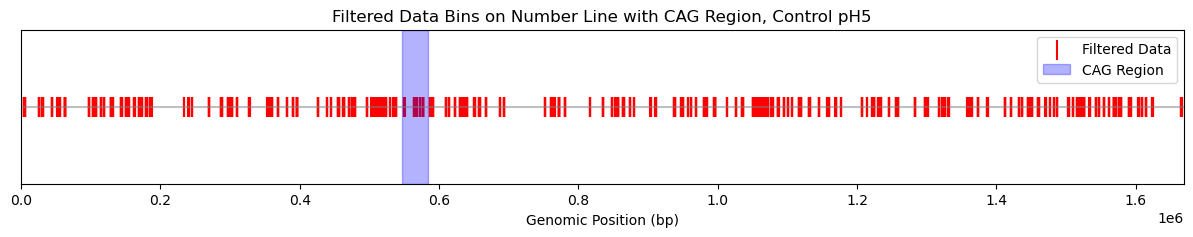

In [363]:
start_range = 0
end_range = 1668732

filtered_starts = filtered_data_ars5['start']

cag_start = 547328
cag_end = 583478

plt.figure(figsize=(15, 2))
plt.hlines(1, xmin=start_range, xmax=end_range, color='grey', alpha=0.5)  # Base line

plt.scatter(filtered_starts, [1] * len(filtered_starts), color='red', marker='|', s=200, label='Filtered Data')

plt.axvspan(cag_start, cag_end, color='blue', alpha=0.3, label='CAG Region')

plt.xlim(start_range, end_range)
plt.yticks([])
plt.xlabel('Genomic Position (bp)')
plt.title('Filtered Data Bins on Number Line with CAG Region, Control pH5')

plt.legend()

plt.show()

In [365]:
unique_gene_ids_a5 = filtered_data_ars5['gene_ID'].unique().tolist()
annot_filtered_a5 = annot[annot['HP_number'].isin(unique_gene_ids_a5)]
annot_filtered_a5

,HP_number,start,end,Putative_Id,Orf_Size,strand
5,HP0006,3403,4230,pantoate-beta-alanine ligase (panC) {Bacillus ...,827,+
8,HP0009,5244,7145,outer membrane protein (omp1),1901,-
24,HP0025,23327,25459,outer membrane protein (omp2),2132,-
28,HP0029,29414,30067,dethiobiotin synthetase (bioD) {Methanococcus ...,653,-
29,HP0030,30074,31852,hypothetical protein,1778,-
...,...,...,...,...,...,...
1528,HP1529,1607627,1608997,chromosomal replication initiator protein (dna...,1370,-
1533,HP1534,1613004,1614284,IS605 transposase (tnpB) {Helicobacter pylori},1280,-
1534,HP1535,1614354,1614779,IS605 transposase (tnpA) {Helicobacter pylori},425,+
1544,HP1545,1623817,1624998,folylpolyglutamate synthase (folC) {Haemophilu...,1181,-


In [371]:
hypo_genes_a5 = annot_filtered_a5['HP_number'].tolist()
hypo_genes_a5

['HP0006',
 'HP0009',
 'HP0025',
 'HP0029',
 'HP0030',
 'HP0052',
 'HP0053',
 'HP0054',
 'HP0058',
 'HP0059',
 'HP0091',
 'HP0098',
 'HP0099',
 'HP0101',
 'HP0107',
 'HP0111',
 'HP0118',
 'HP0119',
 'HP0120',
 'HP0132',
 'HP0133',
 'HP0139',
 'HP0140',
 'HP0141',
 'HP0142',
 'HP0143',
 'HP0152',
 'HP0153',
 'HP0160',
 'HP0163',
 'HP0164',
 'HP0165',
 'HP0166',
 'HP0172',
 'HP0173',
 'HP0174',
 'HP0178',
 'HP0180',
 'HP0225',
 'HP0229',
 'HP0230',
 'HP0259',
 'HP0260',
 'HP0278',
 'HP0279',
 'HP0280',
 'HP0281',
 'HP0286',
 'HP0289',
 'HP0293',
 'HP0311',
 'HP0312',
 'HP0346',
 'HP0349',
 'HP0350',
 'HP0351',
 'HP0358',
 'HP0373',
 'HP0380',
 'HP0385',
 'HP0386',
 'HP0387',
 'HP0423',
 'HP0427',
 'HP0438',
 'HP0439',
 'HP0444',
 'HP0453',
 'HP0455',
 'HP0456',
 'HP0457',
 'HP0459',
 'HP0474',
 'HP0480',
 'HP0481',
 'HP0483',
 'HP0484',
 'HP0486',
 'HP0488',
 'HP0489',
 'HP0493',
 'HP0496',
 'HP0497',
 'HP0498',
 'HP0502',
 'HP0508',
 'HP0510',
 'HP0511',
 'HP0524',
 'HP0531',
 'HP0536',

## Finding Differences

In [426]:
hypo_genes_c7

['HP0006',
 'HP0025',
 'HP0029',
 'HP0030',
 'HP0052',
 'HP0053',
 'HP0054',
 'HP0056',
 'HP0058',
 'HP0059',
 'HP0091',
 'HP0098',
 'HP0101',
 'HP0107',
 'HP0111',
 'HP0118',
 'HP0119',
 'HP0120',
 'HP0132',
 'HP0133',
 'HP0139',
 'HP0141',
 'HP0142',
 'HP0143',
 'HP0172',
 'HP0173',
 'HP0174',
 'HP0178',
 'HP0180',
 'HP0225',
 'HP0229',
 'HP0230',
 'HP0278',
 'HP0279',
 'HP0286',
 'HP0289',
 'HP0293',
 'HP0311',
 'HP0312',
 'HP0349',
 'HP0350',
 'HP0351',
 'HP0358',
 'HP0373',
 'HP0380',
 'HP0385',
 'HP0386',
 'HP0387',
 'HP0405',
 'HP0423',
 'HP0427',
 'HP0438',
 'HP0439',
 'HP0453',
 'HP0455',
 'HP0456',
 'HP0457',
 'HP0459',
 'HP0474',
 'HP0480',
 'HP0481',
 'HP0483',
 'HP0484',
 'HP0486',
 'HP0488',
 'HP0489',
 'HP0493',
 'HP0496',
 'HP0497',
 'HP0498',
 'HP0502',
 'HP0508',
 'HP0510',
 'HP0511',
 'HP0524',
 'HP0531',
 'HP0536',
 'HP0540',
 'HP0541',
 'HP0544',
 'HP0550',
 'HP0554',
 'HP0555',
 'HP0556',
 'HP0578',
 'HP0579',
 'HP0583',
 'HP0591',
 'HP0592',
 'HP0596',
 'HP0598',

In [442]:
hypo_genes_c5

['HP0006',
 'HP0009',
 'HP0025',
 'HP0029',
 'HP0030',
 'HP0052',
 'HP0053',
 'HP0054',
 'HP0056',
 'HP0058',
 'HP0059',
 'HP0091',
 'HP0098',
 'HP0099',
 'HP0107',
 'HP0111',
 'HP0118',
 'HP0119',
 'HP0120',
 'HP0132',
 'HP0133',
 'HP0139',
 'HP0140',
 'HP0141',
 'HP0142',
 'HP0143',
 'HP0152',
 'HP0153',
 'HP0172',
 'HP0173',
 'HP0174',
 'HP0178',
 'HP0180',
 'HP0225',
 'HP0229',
 'HP0230',
 'HP0278',
 'HP0279',
 'HP0286',
 'HP0289',
 'HP0293',
 'HP0311',
 'HP0312',
 'HP0317',
 'HP0318',
 'HP0349',
 'HP0350',
 'HP0351',
 'HP0358',
 'HP0373',
 'HP0385',
 'HP0386',
 'HP0387',
 'HP0405',
 'HP0423',
 'HP0427',
 'HP0438',
 'HP0439',
 'HP0453',
 'HP0455',
 'HP0456',
 'HP0457',
 'HP0459',
 'HP0474',
 'HP0480',
 'HP0481',
 'HP0483',
 'HP0484',
 'HP0486',
 'HP0488',
 'HP0489',
 'HP0493',
 'HP0496',
 'HP0497',
 'HP0498',
 'HP0502',
 'HP0508',
 'HP0510',
 'HP0524',
 'HP0531',
 'HP0536',
 'HP0540',
 'HP0541',
 'HP0543',
 'HP0544',
 'HP0550',
 'HP0554',
 'HP0555',
 'HP0556',
 'HP0578',
 'HP0579',

In [448]:
hypo_genes_a7

['HP0006',
 'HP0009',
 'HP0025',
 'HP0029',
 'HP0030',
 'HP0052',
 'HP0053',
 'HP0054',
 'HP0056',
 'HP0058',
 'HP0059',
 'HP0091',
 'HP0098',
 'HP0099',
 'HP0107',
 'HP0111',
 'HP0118',
 'HP0119',
 'HP0120',
 'HP0132',
 'HP0133',
 'HP0139',
 'HP0140',
 'HP0141',
 'HP0142',
 'HP0143',
 'HP0152',
 'HP0153',
 'HP0160',
 'HP0161',
 'HP0163',
 'HP0164',
 'HP0165',
 'HP0166',
 'HP0172',
 'HP0173',
 'HP0174',
 'HP0178',
 'HP0180',
 'HP0225',
 'HP0229',
 'HP0230',
 'HP0259',
 'HP0260',
 'HP0278',
 'HP0279',
 'HP0280',
 'HP0281',
 'HP0286',
 'HP0289',
 'HP0293',
 'HP0311',
 'HP0312',
 'HP0346',
 'HP0349',
 'HP0350',
 'HP0351',
 'HP0358',
 'HP0373',
 'HP0380',
 'HP0385',
 'HP0386',
 'HP0387',
 'HP0405',
 'HP0423',
 'HP0427',
 'HP0438',
 'HP0439',
 'HP0444',
 'HP0453',
 'HP0455',
 'HP0456',
 'HP0457',
 'HP0459',
 'HP0474',
 'HP0480',
 'HP0481',
 'HP0483',
 'HP0484',
 'HP0486',
 'HP0488',
 'HP0489',
 'HP0493',
 'HP0496',
 'HP0497',
 'HP0498',
 'HP0499',
 'HP0502',
 'HP0508',
 'HP0510',
 'HP0511',

In [450]:
hypo_genes_a5

['HP0006',
 'HP0009',
 'HP0025',
 'HP0029',
 'HP0030',
 'HP0052',
 'HP0053',
 'HP0054',
 'HP0058',
 'HP0059',
 'HP0091',
 'HP0098',
 'HP0099',
 'HP0101',
 'HP0107',
 'HP0111',
 'HP0118',
 'HP0119',
 'HP0120',
 'HP0132',
 'HP0133',
 'HP0139',
 'HP0140',
 'HP0141',
 'HP0142',
 'HP0143',
 'HP0152',
 'HP0153',
 'HP0160',
 'HP0163',
 'HP0164',
 'HP0165',
 'HP0166',
 'HP0172',
 'HP0173',
 'HP0174',
 'HP0178',
 'HP0180',
 'HP0225',
 'HP0229',
 'HP0230',
 'HP0259',
 'HP0260',
 'HP0278',
 'HP0279',
 'HP0280',
 'HP0281',
 'HP0286',
 'HP0289',
 'HP0293',
 'HP0311',
 'HP0312',
 'HP0346',
 'HP0349',
 'HP0350',
 'HP0351',
 'HP0358',
 'HP0373',
 'HP0380',
 'HP0385',
 'HP0386',
 'HP0387',
 'HP0423',
 'HP0427',
 'HP0438',
 'HP0439',
 'HP0444',
 'HP0453',
 'HP0455',
 'HP0456',
 'HP0457',
 'HP0459',
 'HP0474',
 'HP0480',
 'HP0481',
 'HP0483',
 'HP0484',
 'HP0486',
 'HP0488',
 'HP0489',
 'HP0493',
 'HP0496',
 'HP0497',
 'HP0498',
 'HP0502',
 'HP0508',
 'HP0510',
 'HP0511',
 'HP0524',
 'HP0531',
 'HP0536',

In [454]:
set_a5 = set(hypo_genes_a5)
set_a7 = set(hypo_genes_a7)

unique_to_a5 = set_a5 - set_a7
unique_to_a7 = set_a7 - set_a5

print("Genes unique to hypo_genes_a5:")
print(unique_to_a5)

print("Genes unique to hypo_genes_a7:")
print(unique_to_a7)

Genes unique to hypo_genes_a5:
{'HP1300', 'HP0725', 'HP0648', 'HP0808', 'HP1453', 'HP1247', 'HP0647', 'HP0809', 'HP1301', 'HP1302', 'HP0101'}
Genes unique to hypo_genes_a7:
{'HP0707', 'HP0499', 'HP1156', 'HP0056', 'HP1522', 'HP0161', 'HP1564', 'HP1155', 'HP0405'}


In [468]:
unique_a5 = annot[annot['HP_number'].isin(unique_to_a5)]
unique_a5['Putative_Id'].to_list()

['hypothetical protein',
 'hypothetical protein',
 'UDP-N-acetylglucosamine enolpyruvyl transferase (murZ) {Haemophilus influenzae}',
 'outer membrane protein (omp17)',
 'holo-acp synthase (acpS) {Escherichia coli}',
 'hypothetical protein',
 'hypothetical protein',
 'preprotein translocase subunit (secY) {Escherichia coli}',
 'ribosomal protein L15 (rpl15) {Haemophilus influenzae}',
 'ribosomal protein S5 (rps5) {Bacillus stearothermophilus}',
 'conserved hypothetical protein {Helicobacter pylori}']

In [472]:
unique_a7 = annot[annot['HP_number'].isin(unique_to_a7)]
unique_a7['HP_number'].to_list()

['HP0056',
 'HP0161',
 'HP0405',
 'HP0499',
 'HP0707',
 'HP1155',
 'HP1156',
 'HP1522',
 'HP1564']

In [456]:
set_c5 = set(hypo_genes_c5)
set_c7 = set(hypo_genes_c7)

unique_to_c5 = set_c5 - set_c7
unique_to_c7 = set_c7 - set_c5

print("Genes unique to hypo_genes_c5:")
print(unique_to_c5)

print("Genes unique to hypo_genes_c7:")
print(unique_to_c7)

Genes unique to hypo_genes_c5:
{'HP1300', 'HP0009', 'HP1302', 'HP0543', 'HP0152', 'HP0140', 'HP1301', 'HP1473', 'HP0318', 'HP0099', 'HP0317', 'HP0153'}
Genes unique to hypo_genes_c7:
{'HP1188', 'HP0380', 'HP1247', 'HP0887', 'HP0511', 'HP1522', 'HP0101', 'HP0600'}


In [476]:
unique_c5 = annot[annot['HP_number'].isin(unique_to_c5)]
unique_c5['HP_number'].to_list()

['HP0009',
 'HP0099',
 'HP0140',
 'HP0152',
 'HP0153',
 'HP0317',
 'HP0318',
 'HP0543',
 'HP1300',
 'HP1301',
 'HP1302',
 'HP1473']

In [480]:
unique_c7 = annot[annot['HP_number'].isin(unique_to_c7)]
unique_c7['Putative_Id'].to_list()

['hypothetical protein',
 'glutamate dehydrogenase (gdhA) {Eschericha coli}',
 'hypothetical protein',
 'multidrug resistance protein (spaB) {Bacillus subtilis}',
 'vacuolating cytotoxin {Helicobacter pylori}',
 'hypothetical protein',
 'hypothetical protein',
 'adenine specific DNA methyltransferase (mod) {Escherichia coli}']

## creating venn diagram

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib_venn import venn4

ModuleNotFoundError: No module named 'matplotlib_venn'

In [18]:
from matplotlib_venn import venn4

ModuleNotFoundError: No module named 'matplotlib_venn'

In [14]:
control_pH7_genes = [
    'HP0006', 'HP0025', 'HP0029', 'HP0030', 'HP0052', 'HP0053', 'HP0054', 'HP0056', 'HP0058', 'HP0059', 'HP0091',
    'HP0098', 'HP0101', 'HP0107', 'HP0111', 'HP0118', 'HP0119', 'HP0120', 'HP0132', 'HP0133', 'HP0139', 'HP0141',
    'HP0142', 'HP0143', 'HP0172', 'HP0173', 'HP0174', 'HP0178', 'HP0180', 'HP0225', 'HP0229', 'HP0230', 'HP0278',
    'HP0279', 'HP0286', 'HP0289', 'HP0293', 'HP0311', 'HP0312', 'HP0349', 'HP0350', 'HP0351', 'HP0358', 'HP0373',
    'HP0380', 'HP0385', 'HP0386', 'HP0387', 'HP0405', 'HP0423', 'HP0427', 'HP0438', 'HP0439', 'HP0453', 'HP0455',
    'HP0456', 'HP0457', 'HP0459', 'HP0474', 'HP0480', 'HP0481', 'HP0483', 'HP0484', 'HP0486', 'HP0488', 'HP0489',
    'HP0493', 'HP0496', 'HP0497', 'HP0498', 'HP0502', 'HP0508', 'HP0510', 'HP0511', 'HP0524', 'HP0531', 'HP0536',
    'HP0540', 'HP0541', 'HP0544', 'HP0550', 'HP0554', 'HP0555', 'HP0556', 'HP0578', 'HP0579', 'HP0583', 'HP0591',
    'HP0592', 'HP0596', 'HP0598', 'HP0600', 'HP0602', 'HP0603', 'HP0604', 'HP0609', 'HP0610', 'HP0613', 'HP0621',
    'HP0640', 'HP0647', 'HP0648', 'HP0699', 'HP0708', 'HP0709', 'HP0710', 'HP0718', 'HP0725', 'HP0761', 'HP0762',
    'HP0781', 'HP0791', 'HP0796', 'HP0799', 'HP0800', 'HP0801', 'HP0802', 'HP0803', 'HP0821', 'HP0827', 'HP0828',
    'HP0851', 'HP0852', 'HP0857', 'HP0858', 'HP0885', 'HP0886', 'HP0887', 'HP0896', 'HP0906', 'HP0910', 'HP0922',
    'HP0934', 'HP0936', 'HP0954', 'HP0966', 'HP0972', 'HP0973', 'HP0974', 'HP0987', 'HP0991', 'HP0992', 'HP0993',
    'HP0994', 'HP0995', 'HP0996', 'HP1000', 'HP1003', 'HP1005', 'HP1007', 'HP1009', 'HP1012', 'HP1013', 'HP1014',
    'HP1015', 'HP1022', 'HP1023', 'HP1033', 'HP1034', 'HP1044', 'HP1054', 'HP1055', 'HP1056', 'HP1057', 'HP1072',
    'HP1073', 'HP1086', 'HP1099', 'HP1100', 'HP1106', 'HP1107', 'HP1114', 'HP1144', 'HP1152', 'HP1155', 'HP1156',
    'HP1157', 'HP1166', 'HP1168', 'HP1177', 'HP1186', 'HP1188', 'HP1206', 'HP1224', 'HP1225', 'HP1242', 'HP1247',
    'HP1249', 'HP1250', 'HP1255', 'HP1256', 'HP1282', 'HP1285', 'HP1286', 'HP1287', 'HP1288', 'HP1327', 'HP1328',
    'HP1351', 'HP1352', 'HP1360', 'HP1369', 'HP1370', 'HP1380', 'HP1381', 'HP1387', 'HP1389', 'HP1398', 'HP1400',
    'HP1404', 'HP1412', 'HP1416', 'HP1417', 'HP1433', 'HP1444', 'HP1445', 'HP1450', 'HP1452', 'HP1454', 'HP1461',
    'HP1470', 'HP1488', 'HP1495', 'HP1496', 'HP1503', 'HP1506', 'HP1516', 'HP1517', 'HP1522', 'HP1523', 'HP1526',
    'HP1529', 'HP1534', 'HP1535', 'HP1545', 'HP1564', 'HP1587'
]

control_pH5_genes = [
    'HP0006', 'HP0009', 'HP0025', 'HP0029', 'HP0030', 'HP0052', 'HP0053', 'HP0054', 'HP0056', 'HP0058', 'HP0059',
    'HP0091', 'HP0098', 'HP0099', 'HP0107', 'HP0111', 'HP0118', 'HP0119', 'HP0120', 'HP0132', 'HP0133', 'HP0139',
    'HP0140', 'HP0141', 'HP0142', 'HP0143', 'HP0152', 'HP0153', 'HP0172', 'HP0173', 'HP0174', 'HP0178', 'HP0180',
    'HP0225', 'HP0229', 'HP0230', 'HP0278', 'HP0279', 'HP0286', 'HP0289', 'HP0293', 'HP0311', 'HP0312', 'HP0317',
    'HP0318', 'HP0349', 'HP0350', 'HP0351', 'HP0358', 'HP0373', 'HP0385', 'HP0386', 'HP0387', 'HP0405', 'HP0423',
    'HP0427', 'HP0438', 'HP0439', 'HP0453', 'HP0455', 'HP0456', 'HP0457', 'HP0459', 'HP0474', 'HP0480', 'HP0481',
    'HP0483', 'HP0484', 'HP0486', 'HP0488', 'HP0489', 'HP0493', 'HP0496', 'HP0497', 'HP0498', 'HP0502', 'HP0508',
    'HP0510', 'HP0524', 'HP0531', 'HP0536', 'HP0540', 'HP0541', 'HP0543', 'HP0544', 'HP0550', 'HP0554', 'HP0555',
    'HP0556', 'HP0578', 'HP0579', 'HP0583', 'HP0591', 'HP0592', 'HP0596', 'HP0598', 'HP0602', 'HP0603', 'HP0604',
    'HP0609', 'HP0610', 'HP0613', 'HP0621', 'HP0640', 'HP0647', 'HP0648', 'HP0699', 'HP0708', 'HP0709', 'HP0710',
    'HP0718', 'HP0725', 'HP0761', 'HP0762', 'HP0781', 'HP0791', 'HP0796', 'HP0799', 'HP0800', 'HP0801', 'HP0802',
    'HP0803', 'HP0821', 'HP0827', 'HP0828', 'HP0851', 'HP0852', 'HP0857', 'HP0858', 'HP0885', 'HP0886', 'HP0896',
    'HP0906', 'HP0910', 'HP0922', 'HP0934', 'HP0936', 'HP0954', 'HP0966', 'HP0972', 'HP0973', 'HP0974', 'HP0987',
    'HP0991', 'HP0992', 'HP0993', 'HP0994', 'HP0995', 'HP0996', 'HP1000', 'HP1003', 'HP1005', 'HP1007', 'HP1009',
    'HP1012', 'HP1013', 'HP1014', 'HP1015', 'HP1022', 'HP1023', 'HP1033', 'HP1034', 'HP1044', 'HP1054', 'HP1055',
    'HP1056', 'HP1057', 'HP1072', 'HP1073', 'HP1086', 'HP1099', 'HP1100', 'HP1106', 'HP1107', 'HP1114', 'HP1144',
    'HP1152', 'HP1155', 'HP1156', 'HP1157', 'HP1166', 'HP1168', 'HP1177', 'HP1186', 'HP1206', 'HP1224', 'HP1225',
    'HP1242', 'HP1249', 'HP1250', 'HP1255', 'HP1256', 'HP1282', 'HP1285', 'HP1286', 'HP1287', 'HP1288', 'HP1300',
    'HP1301', 'HP1302', 'HP1327', 'HP1328', 'HP1351', 'HP1352', 'HP1360', 'HP1369', 'HP1370', 'HP1380', 'HP1381',
    'HP1387', 'HP1389', 'HP1398', 'HP1400', 'HP1404', 'HP1412', 'HP1416', 'HP1417', 'HP1433', 'HP1444', 'HP1445',
    'HP1450', 'HP1452', 'HP1454', 'HP1461', 'HP1470', 'HP1473', 'HP1488', 'HP1495', 'HP1496', 'HP1503', 'HP1506',
    'HP1516', 'HP1517', 'HP1523', 'HP1526', 'HP1529', 'HP1534', 'HP1535', 'HP1545', 'HP1564', 'HP1587'
]

arsS_pH5_genes = [
    'HP0006', 'HP0009', 'HP0025', 'HP0029', 'HP0030', 'HP0052', 'HP0053', 'HP0054', 'HP0058', 'HP0059', 'HP0091',
    'HP0098', 'HP0099', 'HP0101', 'HP0107', 'HP0111', 'HP0118', 'HP0119', 'HP0120', 'HP0132', 'HP0133', 'HP0139',
    'HP0140', 'HP0141', 'HP0142', 'HP0143', 'HP0152', 'HP0153', 'HP0160', 'HP0163', 'HP0164', 'HP0165', 'HP0166',
    'HP0172', 'HP0173', 'HP0174', 'HP0178', 'HP0180', 'HP0225', 'HP0229', 'HP0230', 'HP0259', 'HP0260', 'HP0278',
    'HP0279', 'HP0280', 'HP0281', 'HP0286', 'HP0289', 'HP0293', 'HP0311', 'HP0312', 'HP0346', 'HP0349', 'HP0350',
    'HP0351', 'HP0358', 'HP0373', 'HP0380', 'HP0385', 'HP0386', 'HP0387', 'HP0423', 'HP0427', 'HP0438', 'HP0439',
    'HP0444', 'HP0453', 'HP0455', 'HP0456', 'HP0457', 'HP0459', 'HP0474', 'HP0480', 'HP0481', 'HP0483', 'HP0484',
    'HP0486', 'HP0488', 'HP0489', 'HP0493', 'HP0496', 'HP0497', 'HP0498', 'HP0502', 'HP0508', 'HP0510', 'HP0511',
    'HP0524', 'HP0531', 'HP0536', 'HP0540', 'HP0541', 'HP0544', 'HP0550', 'HP0554', 'HP0555', 'HP0556', 'HP0578',
    'HP0579', 'HP0583', 'HP0591', 'HP0592', 'HP0596', 'HP0598', 'HP0600', 'HP0602', 'HP0603', 'HP0604', 'HP0609',
    'HP0610', 'HP0613', 'HP0621', 'HP0640', 'HP0647', 'HP0648', 'HP0699', 'HP0706', 'HP0708', 'HP0709', 'HP0710',
    'HP0717', 'HP0718', 'HP0725', 'HP0761', 'HP0762', 'HP0781', 'HP0791', 'HP0796', 'HP0799', 'HP0800', 'HP0801',
    'HP0802', 'HP0803', 'HP0808', 'HP0809', 'HP0821', 'HP0827', 'HP0828', 'HP0851', 'HP0852', 'HP0857', 'HP0858',
    'HP0885', 'HP0886', 'HP0887', 'HP0896', 'HP0906', 'HP0910', 'HP0922', 'HP0934', 'HP0936', 'HP0954', 'HP0966',
    'HP0972', 'HP0973', 'HP0974', 'HP0987', 'HP0991', 'HP0992', 'HP0993', 'HP0994', 'HP0995', 'HP0996', 'HP1000',
    'HP1003', 'HP1005', 'HP1007', 'HP1009', 'HP1012', 'HP1013', 'HP1014', 'HP1015', 'HP1022', 'HP1023', 'HP1033',
    'HP1034', 'HP1041', 'HP1044', 'HP1054', 'HP1055', 'HP1056', 'HP1057', 'HP1072', 'HP1073', 'HP1086', 'HP1099',
    'HP1100', 'HP1106', 'HP1107', 'HP1114', 'HP1144', 'HP1152', 'HP1157', 'HP1166', 'HP1168', 'HP1177', 'HP1186',
    'HP1188', 'HP1206', 'HP1221', 'HP1222', 'HP1224', 'HP1225', 'HP1242', 'HP1247', 'HP1248', 'HP1249', 'HP1250',
    'HP1255', 'HP1256', 'HP1282', 'HP1285', 'HP1286', 'HP1287', 'HP1288', 'HP1300', 'HP1301', 'HP1302', 'HP1327',
    'HP1328', 'HP1351', 'HP1352', 'HP1360', 'HP1369', 'HP1370', 'HP1372', 'HP1380', 'HP1381', 'HP1387', 'HP1389',
    'HP1398', 'HP1400', 'HP1404', 'HP1412', 'HP1416', 'HP1417', 'HP1433', 'HP1444', 'HP1445', 'HP1450', 'HP1452',
    'HP1453', 'HP1454', 'HP1455', 'HP1456', 'HP1461', 'HP1470', 'HP1473', 'HP1480', 'HP1488', 'HP1495', 'HP1496',
    'HP1498', 'HP1499', 'HP1503', 'HP1506', 'HP1516', 'HP1517', 'HP1523', 'HP1526', 'HP1529', 'HP1534', 'HP1535',
    'HP1545', 'HP1587'
]

arsS_pH7_genes = [
    'HP0006', 'HP0009', 'HP0025', 'HP0029', 'HP0030', 'HP0052', 'HP0053', 'HP0054', 'HP0056', 'HP0058', 'HP0059',
    'HP0091', 'HP0098', 'HP0099', 'HP0107', 'HP0111', 'HP0118', 'HP0119', 'HP0120', 'HP0132', 'HP0133', 'HP0139',
    'HP0140', 'HP0141', 'HP0142', 'HP0143', 'HP0152', 'HP0153', 'HP0160', 'HP0161', 'HP0163', 'HP0164', 'HP0165',
    'HP0166', 'HP0172', 'HP0173', 'HP0174', 'HP0178', 'HP0180', 'HP0225', 'HP0229', 'HP0230', 'HP0259', 'HP0260',
    'HP0278', 'HP0279', 'HP0280', 'HP0281', 'HP0286', 'HP0289', 'HP0293', 'HP0311', 'HP0312', 'HP0346', 'HP0349',
    'HP0350', 'HP0351', 'HP0358', 'HP0373', 'HP0380', 'HP0385', 'HP0386', 'HP0387', 'HP0405', 'HP0423', 'HP0427',
    'HP0438', 'HP0439', 'HP0444', 'HP0453', 'HP0455', 'HP0456', 'HP0457', 'HP0459', 'HP0474', 'HP0480', 'HP0481',
    'HP0483', 'HP0484', 'HP0486', 'HP0488', 'HP0489', 'HP0493', 'HP0496', 'HP0497', 'HP0498', 'HP0499', 'HP0502',
    'HP0508', 'HP0510', 'HP0511', 'HP0524', 'HP0531', 'HP0536', 'HP0540', 'HP0541', 'HP0544', 'HP0550', 'HP0554',
    'HP0555', 'HP0556', 'HP0578', 'HP0579', 'HP0583', 'HP0591', 'HP0592', 'HP0596', 'HP0598', 'HP0600', 'HP0602',
    'HP0603', 'HP0604', 'HP0609', 'HP0610', 'HP0613', 'HP0621', 'HP0640', 'HP0699', 'HP0706', 'HP0707', 'HP0708',
    'HP0709', 'HP0710', 'HP0717', 'HP0718', 'HP0761', 'HP0762', 'HP0781', 'HP0791', 'HP0796', 'HP0799', 'HP0800',
    'HP0801', 'HP0802', 'HP0803', 'HP0821', 'HP0827', 'HP0828', 'HP0851', 'HP0852', 'HP0857', 'HP0858', 'HP0885',
    'HP0886', 'HP0887', 'HP0896', 'HP0906', 'HP0910', 'HP0922', 'HP0934', 'HP0936', 'HP0954', 'HP0966', 'HP0972',
    'HP0973', 'HP0974', 'HP0987', 'HP0991', 'HP0992', 'HP0993', 'HP0994', 'HP0995', 'HP0996', 'HP1000', 'HP1003',
    'HP1005', 'HP1007', 'HP1009', 'HP1012', 'HP1013', 'HP1014', 'HP1015', 'HP1022', 'HP1023', 'HP1033', 'HP1034',
    'HP1041', 'HP1044', 'HP1054', 'HP1055', 'HP1056', 'HP1057', 'HP1072', 'HP1073', 'HP1086', 'HP1099', 'HP1100',
    'HP1106', 'HP1107', 'HP1114', 'HP1144', 'HP1152', 'HP1155', 'HP1156', 'HP1157', 'HP1166', 'HP1168', 'HP1177',
    'HP1186', 'HP1188', 'HP1206', 'HP1221', 'HP1222', 'HP1224', 'HP1225', 'HP1242', 'HP1248', 'HP1249', 'HP1250',
    'HP1255', 'HP1256', 'HP1282', 'HP1285', 'HP1286', 'HP1287', 'HP1288', 'HP1327', 'HP1328', 'HP1351', 'HP1352',
    'HP1360', 'HP1369', 'HP1370', 'HP1372', 'HP1380', 'HP1381', 'HP1387', 'HP1389', 'HP1398', 'HP1400', 'HP1404',
    'HP1412', 'HP1416', 'HP1417', 'HP1433', 'HP1444', 'HP1445', 'HP1450', 'HP1452', 'HP1454', 'HP1455', 'HP1456',
    'HP1461', 'HP1470', 'HP1473', 'HP1480', 'HP1488', 'HP1495', 'HP1496', 'HP1498', 'HP1499', 'HP1503', 'HP1506',
    'HP1516', 'HP1517', 'HP1522', 'HP1523', 'HP1526', 'HP1529', 'HP1534', 'HP1535', 'HP1545', 'HP1564', 'HP1587'
]

# Create a list of the hypomethylated genes for each condition
genes_list = {
    "control pH 5": set(control_pH5_genes),
    "control pH 7": set(control_pH7_genes),
    "arsS pH 5": set(arsS_pH5_genes),
    "arsS pH 7": set(arsS_pH7_genes)
}

# Create the Venn diagram
plt.figure(figsize=(10, 8))
venn_diagram = venn4(genes_list, set_labels=("control pH 5", "control pH 7", "arsS pH 5", "arsS pH 7"))
plt.title("Venn Diagram of Hypomethylated Genes by Condition")
plt.show()


NameError: name 'venn4' is not defined

<Figure size 1000x800 with 0 Axes>